In [25]:
from pathlib import Path
import jax.numpy as np
import numpy as onp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)

from gwfast.gwfastGlobals import detectors as det_dict, detPath
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
from gwfast.signals import AGNLensedGWSignal
import gwfast.network as network
from gwfast.fisherTools import reduce_Fisher_matrix, CovMatr, plot_corners

## `Dls_wrt_y_and_R_orbit` definition

In [40]:
def Dls_wrt_y_and_R_orbit(y, R_orbit, rs=1):
    # y has units of einstein radius, R_orbit has units of R_S
    return (np.sqrt(np.square(R_orbit) + np.power(y, 4)) - np.square(y)) * rs

## Detector setup

In [2]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Initializing jax...
Jax local device cou

## Event parameters

In [55]:
n = 5
shape = (n, n)
# A benchmark event, at dL = 1Gpc
events = {
    'Mc':np.full(shape, 30), 'eta':np.full(shape, 0.24),
    'chi1z':np.full(shape, 0.3), 'chi2z':np.full(shape, 0.5),
    'tcoal':np.full(shape, 0), 'phase':np.full(shape, 2),
    'R_orbit':np.full(shape, 100), 'M_lz':np.full(shape, 1e4), 'src_pos':np.full(shape, 0.5),
    'iota':np.full(shape, 0.99*np.pi/2), 'psi':np.full(shape, 4),
    'dL':np.full(shape, 1), 'theta':np.full(shape, 1.87), 'phi':np.full(shape, 2.66),
}
events = {key: val.astype(np.float64) for key, val in events.items()}

# Sample parameter space
y_array = np.linspace(0.2, 2, n) # in Einstein radii
R_orbit_array = np.linspace(10, 1000, n)

R_orbit_mesh, _ = np.meshgrid(R_orbit_array, y_array, indexing='xy')
events['R_orbit'] = R_orbit_mesh

# Convert y to src_pos for injection
Dls_min = Dls_wrt_y_and_R_orbit(1, R_orbit_array) # for rs=1, this is in units of R_S
beta_max = np.sqrt(2 * Dls_min) # Maximum source position (i.e. Einstein radius) in units of R_S
events['src_pos'] = np.outer(y_array, beta_max / R_orbit_array)

## Fisher

In [ ]:
fisher_AGN = HLV_AGN.FisherMatr(events, res=1000)
keys = list(events.keys()).copy()
reduced_fisher_AGN, _ = reduce_Fisher_matrix(fisher_AGN, keys=keys)
reduced_cov_AGN, ie = CovMatr(reduced_fisher_AGN)

Computing Fisher for H1...
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 7.882248849537163, Maximum duration: 24.60698144251176.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 6.316649763603835, Maximum duration: 24.60698144251176.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 24.60698144251176.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 24.60698144251176.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolve

In [57]:
# Plot one selected cov matrix
# Skipped here because this takes quite some time to run
# idx1 = 2
# idx2 = 2
# indices = onp.arange(0, len(keys))
# parameters = {key: val[idx1, idx2] for key, val in events.items()}
# labels = {
#     'Mc': r'${\cal M}\,/\,M_\odot$',
#     'eta': r'$\eta$',
#     'dL': r'$D_{\rm L}\,/\,{\rm Gpc}$',
#     'theta': r'$\alpha\,/\,{\rm rad}$',
#     'phi': r'$\delta\,/\,{\rm rad}$',
#     'iota': r'$\iota\,/\,{\rm rad}$',
#     'psi': r'$\psi\,/\,{\rm rad}$',
#     'tcoal': r'$t_{\rm c}\,/\,{\rm s}$',
#     'phase': r'$\phi\,/\,{\rm rad}$',
#     'chi1z': r'$\chi_{1z}$',
#     'chi2z': r'$\chi_{2z}$',
#     'R_orbit': r'$R_{\rm orb}\,/\,R_{\rm S}$',
#     'M_lz': r'$M_{\rm Lz}\,/\,M_\odot$',
#     'src_pos': r'$y$',
#     'delta_iota': r'$\Delta \iota\,/\,{\rm rad}$',
#     'delta_phase': r'$\Delta \phi\,/\,{\rm rad}$',
#     'delta_time': r'$\Delta t\,/\,{\rm s}$',
#     'relative_mass': r'${\cal M}_2 \,/\,{\cal M}_1$',
#     'relative_distance': r'$D_{L,2} \,/\,D_{L,1}$',
# }
# fig = plot_corners(
#     reduced_cov_AGN[:, :, idx1, idx2], keys, indices, 
#     event=parameters, labels=labels, color='C0'
# )

## Money plot demo

Text(0, 0.5, '$y\\,\\equiv\\,\\beta\\,/\\,\\theta_E$')

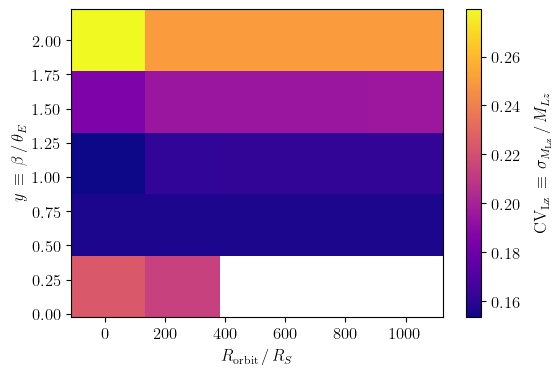

In [58]:
idx_M_lz = 7
std_M_lz = onp.sqrt(reduced_cov_AGN[idx_M_lz, idx_M_lz, :, :])
CV_M_lz = std_M_lz / onp.asarray(events['M_lz'])

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
im = ax.pcolormesh(R_orbit_array, y_array, CV_M_lz, cmap='plasma',
                #    norm=LogNorm()
                   )
cbar = fig.colorbar(im, ax=ax, label=r'${\rm CV}_{\rm Lz}\,\equiv\,\sigma_{M_{\rm Lz}}\,/\,M_{Lz}$')
cbar.set_label(r'${\rm CV}_{\rm Lz}\,\equiv\,\sigma_{M_{\rm Lz}}\,/\,M_{Lz}$', labelpad=10)
# ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel(r'$R_{\rm orbit}\,/\,R_S$')
ax.set_ylabel(r'$y\,\equiv\,\beta\,/\,\theta_E$')